# Week 2 in class: language models from counts to neural networks

*Generative AI from First Principles*, Lecture 2 · [course page](https://mathrulestheworld.github.io/genai-first-principles/)

This is the notebook we run during the lecture. It has four short stops; each cell runs in a few seconds, or loads a model trained in advance. The data are [TinyStories](https://arxiv.org/abs/2305.07759), short stories in simple English (downloaded into `data/` on the first run, 19 MB).

| Stop | After the slide | What we look at |
|---|---|---|
| 1. Counting | *n-gram Models* | a bigram model of four sentences: its table, its tree, a zero; Shannon's experiment on TinyStories |
| 2. Word vectors | *Vectors from Prediction: word2vec* | neighbors from counts and from prediction; vectors before and after training; analogies; why the two routes agree |
| 3. Neural language models | *The Fixed-Window Model* | gradient descent finds the counts; Bengio's model: what it predicts and what it writes |
| 4. Recurrent networks | *The Fix: an Additive Path* | a recurrent network reading a phrase; LSTM samples; a memory test, plain RNN against LSTM |

Every experiment of the lecture notes, with the code that trains the saved models, is in the full notebook [`week02_language_models.ipynb`](week02_language_models.ipynb), for study after class.

In [1]:
import sys, math, time, pathlib, json
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))                 # use the repository's tinylm without installing it

import numpy as np
import torch
import matplotlib.pyplot as plt
from tinylm.data import tinystories_words, clean_chars, END
from tinylm import ngram, embeddings, neural

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
data = tinystories_words(ROOT / "data")       # the word-level split of the lecture notes
train, test, vocab = data["train"], data["test"], data["vocab"]
char_train = [clean_chars(s) for s in data["stories"][0][:6000]]     # the character-level data: 6,000 stories
char_test = [clean_chars(s) for s in data["stories"][2][:500]]
print(f"{len(train):,} training stories, vocabulary of {len(vocab):,} words")

17,592 training stories, vocabulary of 8,681 words


# 1. Counting

A **bigram model** predicts each word from the one before it, with probabilities equal to relative frequencies in the training text, $q(w\mid h) = c(h,w)/c(h)$. Every sentence starts from BOS (written `<s>`) and ends by predicting END (`</s>`).

*Before running:* which word comes after *the*?

In [2]:
corpus = [s.split() for s in ["the cat sleeps", "the cat eats fish", "the dog sleeps", "a dog eats"]]
toy_vocab = ["the", "a", "cat", "dog", "sleeps", "eats", "fish", END]
bigram = ngram.NGramModel(corpus, 2, toy_vocab)          # counts, no smoothing

print(f"{'previous':>9s} " + " ".join(f"{w:>7s}" for w in toy_vocab))
for h in [ngram.BOS, "the", "a", "cat", "dog", "sleeps", "eats", "fish"]:
    print(f"{h:>9s} " + " ".join(f"{bigram.prob((h,), w):7.2f}" for w in toy_vocab))

 previous     the       a     cat     dog  sleeps    eats    fish    </s>
      <s>    0.75    0.25    0.00    0.00    0.00    0.00    0.00    0.00
      the    0.00    0.00    0.67    0.33    0.00    0.00    0.00    0.00
        a    0.00    0.00    0.00    1.00    0.00    0.00    0.00    0.00
      cat    0.00    0.00    0.00    0.00    0.50    0.50    0.00    0.00
      dog    0.00    0.00    0.00    0.00    0.50    0.50    0.00    0.00
   sleeps    0.00    0.00    0.00    0.00    0.00    0.00    0.00    1.00
     eats    0.00    0.00    0.00    0.00    0.00    0.00    0.50    0.50
     fish    0.00    0.00    0.00    0.00    0.00    0.00    0.00    1.00


**The model as a tree.** Every complete sentence is a path from BOS to an END leaf; its probability is the product of the probabilities along the path. Here is every sentence this model can produce:

In [3]:
def complete_sentences(model, prefix=(), p=1.0):
    # walk the tree of prefixes; each branch adds one word
    for word, q in model.distribution((ngram.BOS,) + prefix).items():
        if q > 0 and word == END:
            yield " ".join(prefix), p * q                  # an END leaf: a complete sentence
        elif q > 0:
            yield from complete_sentences(model, prefix + (word,), p * q)

leaves = sorted(complete_sentences(bigram), key=lambda leaf: -leaf[1])
for sentence, p in leaves:
    print(f"{p:.4f}  {sentence}")
print(f"\n{len(leaves)} sentences, total probability {sum(p for _, p in leaves):.2f}")

0.2500  the cat sleeps
0.1250  the cat eats fish
0.1250  the cat eats
0.1250  the dog sleeps
0.1250  a dog sleeps
0.0625  the dog eats fish
0.0625  the dog eats
0.0625  a dog eats fish
0.0625  a dog eats

9 sentences, total probability 1.00


*the dog eats fish* never occurred, yet it is in the tree: every step of it did occur. *a cat sleeps* is not: *a cat* never occurred, so its probability is **zero**. Counting recombines pieces it has seen and cannot do more.

**Shannon's experiment, repeated.** Character models of TinyStories that choose each character from the previous $n-1$, with probabilities counted in 6,000 stories. At which $n$ do real words appear? Phrases? A story?

In [4]:
alphabet = sorted(set("".join(char_train))) + [END]
rng = np.random.default_rng(3)
for n in [1, 2, 3, 5, 7]:
    model = ngram.NGramModel(char_train, n, alphabet)
    print(f"n = {n}: " + "".join(ngram.sample(model, rng, max_tokens=110)))

n = 1:  ari ef o eheiowamna wactifp oe nu,laoo.smnseot sef nataiel! ooit,s wllwrr d  .t agswo.hn ndinnhi"g ghpe h,oee


n = 2: omame oventotouge foked jir bimilay be d w, sty no pasth anoele s heded junt hend. sed. shed nopomas tow. the,


n = 3: once. the fried to pup. theling, chim aps carelf. tored clow she trienth excithe day st, he it way saing. jobo


n = 5: once upon a time, they are so to learned by even they hated to be one day that how flourful all the came in. i


n = 7: once upon a time, there was a hairy dust an original book store to carrying, he heard some bugs and waved goin


# 2. Word vectors

Two routes to vectors in which words used alike are near each other. **From counts:** count which words occur within two positions of which, reweight the counts by PMI, and compress each row to 100 numbers with an SVD (about 20 seconds). **From prediction:** skip-gram with negative sampling, trained in advance for ten passes over the training stories (about four minutes; the full notebook trains it live). Compare the nearest neighbors, by cosine similarity:

In [5]:
text = embeddings.content_words(train)                           # words only, no punctuation
top_words, word_counts = embeddings.frequent_words(text, how_many=3000)
counts = embeddings.cooccurrence_counts(text, top_words, window=2)
count_vectors = embeddings.svd_vectors(embeddings.ppmi(counts), 100)

w2v = torch.load(ROOT / "checkpoints" / "week02_word2vec.pt")
w2v_words, w2v_vectors = w2v["words"], w2v["after"].numpy()

def neighbors(vectors, words, q, k=4):
    return ", ".join(w for w, s in embeddings.nearest(vectors, words, q, k))

print(f"{'':>7s}  {'from counts':42s}  from prediction (skip-gram)")
for q in ["mom", "red", "happy", "dog", "ran", "cake"]:
    print(f"{q:>7s}  {neighbors(count_vectors, top_words, q):42s}  {neighbors(w2v_vectors, w2v_words, q)}")

         from counts                                 from prediction (skip-gram)
    mom  dad, mommy, mother, mum                     dad, mommy, mother, mum
    red  blue, yellow, green, pink                   yellow, green, blue, polka
  happy  refreshed, content, grateful, relieved      grateful, thankful, thanked, glad
    dog  cat, rex, barks, tail                       rex, barking, barks, barked
    ran  walked, went, headed, jumped                jumped, rushed, grabbed, quickly
   cake  soup, pie, cookies, pizza                   pizza, cookies, oven, baked


**Before and after.** 36 words from six groups, projected to two dimensions (t-SNE, which keeps near neighbors near). Left, the random vectors skip-gram starts from; right, after training. Nothing in the training names a group: the only signal was which words occur near which.

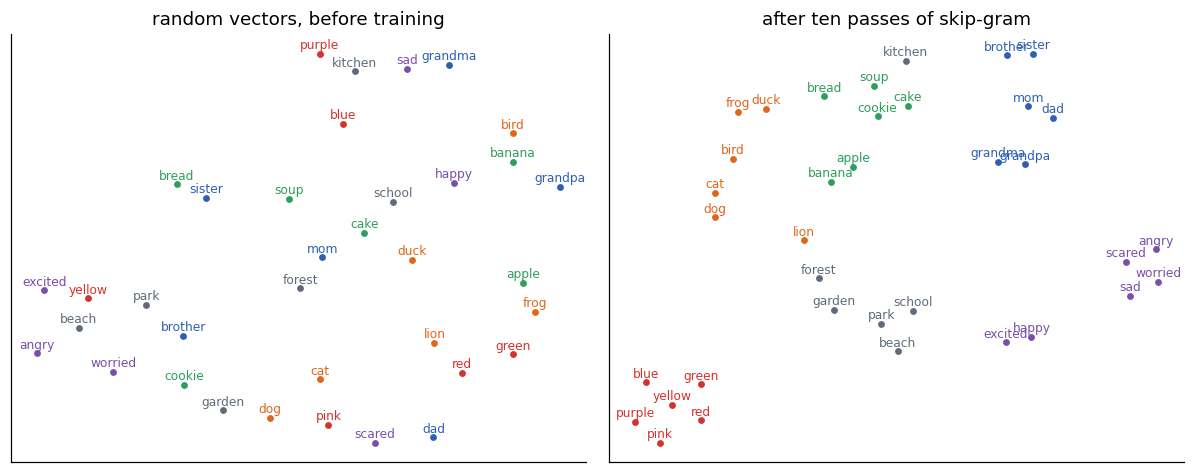

In [6]:
GROUPS = {"colors": ["red", "blue", "green", "yellow", "pink", "purple"],
          "animals": ["dog", "cat", "bird", "frog", "lion", "duck"],
          "family": ["mom", "dad", "sister", "brother", "grandma", "grandpa"],
          "feelings": ["happy", "sad", "scared", "angry", "excited", "worried"],
          "food": ["apple", "cake", "cookie", "banana", "soup", "bread"],
          "places": ["park", "school", "garden", "forest", "beach", "kitchen"]}
COLORS = {"colors": "#D1342F", "animals": "#E0661B", "family": "#2F5FB3",
          "feelings": "#7B4FA8", "food": "#2E9E5B", "places": "#5F6B7A"}

def plot_groups(ax, vectors, words, title):
    from sklearn.manifold import TSNE
    chosen = [(w, g) for g, ws in GROUPS.items() for w in ws]
    unit = embeddings.unit_rows(np.array([vectors[words.index(w)] for w, g in chosen], dtype=np.float32))
    xy = TSNE(n_components=2, perplexity=6, metric="cosine", init="pca", random_state=0).fit_transform(unit)
    for (w, g), (x, y) in zip(chosen, xy):
        ax.scatter(x, y, color=COLORS[g], s=12)
        ax.annotate(w, (x, y), fontsize=8, color=COLORS[g], xytext=(0, 3), textcoords="offset points", ha="center")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
plot_groups(axes[0], w2v["before"].float().numpy(), w2v_words, "random vectors, before training")
plot_groups(axes[1], w2v_vectors, w2v_words, "after ten passes of skip-gram")
plt.tight_layout(); plt.show()

**Analogies.** *a* : *b* :: *c* : ? is answered by vector arithmetic: the word whose vector is nearest to $\mathbf v_b - \mathbf v_a + \mathbf v_c$ (leaving out *a*, *b*, *c*). Relations repeated thousands of times in the stories come out right; rarer ones do not.

In [7]:
for a, b, c in [("boy", "girl", "he"), ("he", "she", "his"), ("mom", "dad", "mommy"), ("run", "ran", "walk"),
                ("boy", "girl", "brother"), ("king", "queen", "prince")]:
    print(f"{a} : {b} :: {c} : ?   " + ", ".join(f"{w} ({s})" for w, s in embeddings.analogy(w2v_vectors, w2v_words, a, b, c)))

boy : girl :: he : ?   she (0.85), her (0.59), molly (0.59)
he : she :: his : ?   her (0.93), lily's (0.73), sally's (0.62)
mom : dad :: mommy : ?   daddy (0.85), mum (0.67), jennifer (0.65)
run : ran :: walk : ?   walked (0.74), winding (0.64), wandered (0.63)
boy : girl :: brother : ?   sister (0.56), mandy's (0.56), her (0.54)
king : queen :: prince : ?   servant (0.68), prince's (0.68), kingdom (0.67)


**Counting meets prediction.** Levy and Goldberg (2014): at its optimum, skip-gram makes the dot product $\mathbf v_w\cdot\mathbf u_c$ equal to a shifted PMI, which can be computed from the pair counts. Each point is a word–context pair seen at least 20 times; on the diagonal, the trained vectors learned exactly what the counts predict.

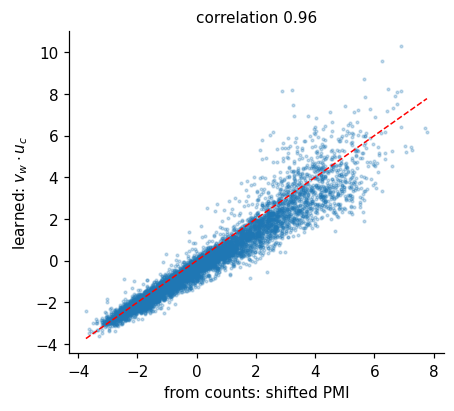

In [8]:
predicted, learned = w2v["pmi_check"].numpy()
plt.figure(figsize=(4.4, 3.8))
plt.scatter(predicted, learned, s=3, alpha=0.25)
lo, hi = predicted.min(), predicted.max()
plt.plot([lo, hi], [lo, hi], "r--", lw=1)
plt.xlabel("from counts: shifted PMI"); plt.ylabel("learned: $v_w \\cdot u_c$")
plt.title(f"correlation {np.corrcoef(predicted, learned)[0, 1]:.2f}", fontsize=10)
plt.show()

# 3. Neural language models

**The bigram model as a network.** One-hot previous character times a weight matrix $W$ gives a score for every next character; the softmax turns the scores into probabilities. Start from $W = 0$ and take 3,000 steps of gradient descent on the log loss (a few seconds). Each row's best value is the relative frequency, so gradient descent must find the count table:

bits per character on the training text: counting 3.262, network 3.262


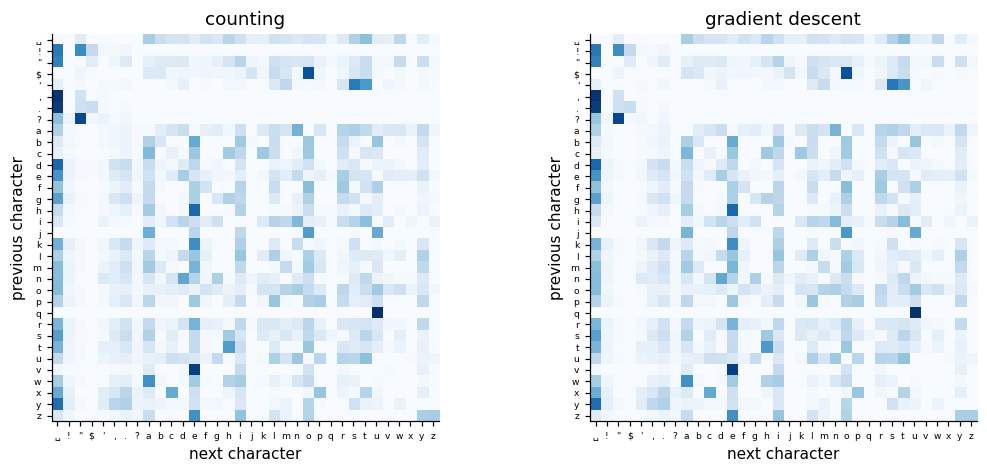

In [9]:
chars = neural.char_alphabet(char_train)
K = len(chars)
stream = torch.cat([torch.tensor([chars.index(neural.STORY_END)]), neural.encode_chars(char_train, chars)])
prev, nxt = stream[:-1], stream[1:]

N = torch.zeros(K, K)
N.index_put_((prev, nxt), torch.ones(len(prev)), accumulate=True)
P_count = N / N.sum(1, keepdim=True)                             # counting

torch.manual_seed(0)
net = neural.BigramNet(K, K)                                     # W starts at zero
opt = torch.optim.Adam(net.parameters(), lr=0.1)
for step in range(3000):
    i = torch.randint(0, len(prev), (4096,))
    loss = torch.nn.functional.cross_entropy(net(prev[i]), nxt[i])
    opt.zero_grad(); loss.backward(); opt.step()
    if step == 2100:
        for g in opt.param_groups: g["lr"] = 0.01
P_net = torch.softmax(net.W.weight.detach(), 1)                  # gradient descent

bits = lambda P: float(-torch.log2(P[prev, nxt]).mean())
print(f"bits per character on the training text: counting {bits(P_count):.3f}, network {bits(P_net):.3f}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, P, title in [(axes[0], P_count, "counting"), (axes[1], P_net, "gradient descent")]:
    ax.imshow(P ** 0.5, cmap="Blues")
    ax.set_xticks(range(K)); ax.set_xticklabels(["␣" if c == " " else c for c in chars], fontsize=6)
    ax.set_yticks(range(K)); ax.set_yticklabels(["␣" if c == " " else c for c in chars], fontsize=6)
    ax.set_title(title); ax.set_xlabel("next character"); ax.set_ylabel("previous character")
plt.tight_layout(); plt.show()

**The fixed-window model** of Bengio et al. (2003): the vectors of the previous four words, side by side, a tanh hidden layer, and a softmax over the vocabulary. This is the whole model; it was trained in advance (two passes over the training stories, about ten minutes):

In [10]:
import inspect
print(inspect.getsource(neural.FixedWindowLM))
index = neural.word_index(vocab)
lm = neural.FixedWindowLM(len(vocab) + 1, len(vocab), context=4, embed_dim=64, hidden=128)
lm.load_state_dict(torch.load(ROOT / "checkpoints" / "week02_fixed_window.pt"))
print(f"{sum(p.numel() for p in lm.parameters()):,} parameters; test perplexity 26.9, against 24.6 for the Kneser-Ney 4-gram (measured in the full notebook)")

class FixedWindowLM(nn.Module):
    """q(next word | previous `context` words) = softmax(b + U tanh(d + H [C(x_1); ...; C(x_k)])).

    C is the word table: one learned vector of size embed_dim per input symbol (the vocabulary
    plus BOS). The vectors of the context words are concatenated, passed through one tanh layer
    (H, d) and turned into scores for every word of the vocabulary (U, b).
    """

    def __init__(self, n_inputs, vocab_size, context=4, embed_dim=64, hidden=128):
        super().__init__()
        self.context = context
        self.C = nn.Embedding(n_inputs, embed_dim)
        self.H = nn.Linear(context * embed_dim, hidden)
        self.U = nn.Linear(hidden, vocab_size)

    def forward(self, x):
        """x: (batch, context) word ids. Returns (batch, vocab_size) scores (logits)."""
        e = self.C(x).flatten(1)                 # (batch, context * embed_dim): the vectors side by side
        h = torch.tanh(self.H(e))                # (batch, hidden)
        r

What it predicts next. *Try your own four-word contexts.*

In [11]:
for prompt in ["she was very", "they went to the", "once upon a", "the dog wagged its"]:
    top = neural.next_word_distribution(lm, index, vocab, prompt.split())
    print(f"{prompt + ' ...':22s} " + ", ".join(f"{w} {p:.2f}" for w, p in top))

she was very ...       excited 0.16, happy 0.10, sad 0.06, proud 0.04, curious 0.04
they went to the ...   park 0.23, kitchen 0.12, store 0.06, beach 0.04, airport 0.03
once upon a ...        time 1.00, long 0.00, place 0.00, sunny 0.00, special 0.00
the dog wagged its ... tail 0.96, friends 0.00, neck 0.00, eyes 0.00, tears 0.00


What it writes, at temperature 0.8. Every four-word stretch is fluent; the story is not. Watch the names: the model sees only four words.

In [12]:
for seed in [1, 2]:
    print(neural.detokenize(neural.sample_words(lm, index, vocab, temperature=0.8, seed=seed)), "\n")

once upon a time, there was a little boy named timmy. timmy loved to play. from that day on, lily thought it was so cool. he looked around and saw a tiny mouse. he was so relieved. it was so heavy! he had to go home. he crossed the store, 

once upon a time, there were two friends, squirrels, and then i will try to learn. he wanted to go home with her. she walked in the station and started to swing, mia can do it! " he said. " hi lily, " lila says. the ostrich is too. 



# 4. Recurrent networks

Character-level networks trained in advance on the same 6,000 stories as the character n-grams (with `tools/train_week02_checkpoints.py`): a plain RNN and an LSTM with 256 units, and an LSTM with 512 units trained twice as long. Their held-out scores, from the training runs:

In [13]:
models = {}
for name, kind, width in [("rnn", "rnn", 256), ("lstm", "lstm", 256), ("lstm512", "lstm", 512)]:
    m = neural.CharRNN(K, kind=kind, hidden=width)
    m.load_state_dict(torch.load(ROOT / "checkpoints" / f"week02_char_{name}.pt"))
    models[name] = m
    info = json.load(open(ROOT / "checkpoints" / f"week02_char_{name}.json"))
    print(f"{kind.upper():5s} {width} units: {info['params']:>9,} parameters, {info['test_bpc']:.2f} bits per character")
print("best character n-gram (n = 10, 4.3 million counts): 1.26 bits per character")

RNN   256 units:    84,066 parameters, 1.47 bits per character


LSTM  256 units:   306,786 parameters, 1.31 bits per character
LSTM  512 units: 1,136,738 parameters, 1.12 bits per character
best character n-gram (n = 10, 4.3 million counts): 1.26 bits per character


**Reading a phrase.** At each step the plain RNN reads one character and gives a distribution over the next. Within a word the choices narrow; at the start of a word it must guess what the story does next.

In [14]:
def read_phrase(model, phrase):
    x = torch.tensor([[chars.index(neural.STORY_END)] + [chars.index(c) for c in phrase]])
    with torch.no_grad():
        P = torch.softmax(model(x)[0][0], -1)
    for t, c in enumerate(phrase):
        top = torch.topk(P[t], 4)
        shown = "  ".join(f"{chars[j]!r} {v:.2f}" for v, j in zip(top.values.tolist(), top.indices.tolist()))
        read = "start" if t == 0 else repr(phrase[t - 1])
        print(f"after {read:7s} next {c!r}: p = {P[t, chars.index(c)]:.2f}   top four: {shown}")

read_phrase(models["rnn"], "the dog barked")

after start   next 't': p = 0.17   top four: 'o' 0.60  't' 0.17  'j' 0.06  'c' 0.04
after 't'     next 'h': p = 0.28   top four: 'o' 0.34  'i' 0.30  'h' 0.28  'a' 0.06
after 'h'     next 'e': p = 0.80   top four: 'e' 0.80  'a' 0.19  'i' 0.01  'o' 0.01
after 'e'     next ' ': p = 0.66   top four: ' ' 0.66  'y' 0.24  'i' 0.08  'n' 0.01
after ' '     next 'd': p = 0.19   top four: 'd' 0.19  's' 0.12  'b' 0.11  'c' 0.08
after 'd'     next 'o': p = 0.54   top four: 'o' 0.54  'i' 0.23  'r' 0.07  'u' 0.06
after 'o'     next 'g': p = 0.38   top four: 'o' 0.42  'g' 0.38  'l' 0.06  'v' 0.04
after 'g'     next ' ': p = 0.72   top four: ' ' 0.72  '.' 0.18  ',' 0.04  '!' 0.02
after ' '     next 'b': p = 0.03   top four: 'w' 0.31  'a' 0.09  'c' 0.09  'f' 0.07
after 'b'     next 'a': p = 0.12   top four: 'e' 0.35  'o' 0.23  'u' 0.13  'a' 0.12
after 'a'     next 'r': p = 0.19   top four: 'c' 0.53  'r' 0.19  'l' 0.12  'd' 0.08
after 'r'     next 'k': p = 0.77   top four: 'k' 0.77  'n' 0.05  's' 0.03  '

**Samples** from the 512-unit LSTM. Temperature $T$ divides the scores before the softmax: $T<1$ sharpens the distribution (safer, more repetitive), $T>1$ flattens it (more varied, more mistakes).

In [15]:
for T in [0.5, 0.8, 1.2]:
    print(f"T = {T}:", neural.sample_chars(models["lstm512"], chars, max_chars=300, temperature=T, seed=1), "\n")

T = 0.5: one day, a little girl was walking around the park. she was so happy that she had learned that it's important to listen to learn new things around her for bed. one day, lily's mom said they would take the toy car in the box and the potatoes. they wanted to keep it safe and warm. they had been still  



T = 0.8: one day, a little girl watched as a big dog running toys and scattered rover. they saw a big red ball in the sand. they hopped and saw it was a good spot. the moral of the story is that it's okay to be kind and grateful for the drink! 

T = 1.2: one day molly and her mom found a almost boat around her house. one day, lily went for a walk in the park when the swull had wander of it. 



**A memory test.** Each sequence is a key (one of eight symbols), then $T$ random noise symbols, then a query; at the query the network must output the key. A network that stores the key is always right; one that does not guesses, right one time in eight. Train a plain RNN and an LSTM from scratch (64 units each, the same budget) with the key 20 steps back (about half a minute):

In [16]:
class MemoryNet(torch.nn.Module):
    def __init__(self, kind, hidden=64, forget_bias=3.0):
        super().__init__()
        self.emb = torch.nn.Embedding(17, 32)
        self.rnn = (torch.nn.LSTM if kind == "lstm" else torch.nn.RNN)(32, hidden, batch_first=True)
        if kind == "lstm":                              # start the forget gates near 1 (PyTorch starts them at 1/2)
            with torch.no_grad():
                self.rnn.bias_ih_l0[hidden:2 * hidden] = forget_bias
                self.rnn.bias_hh_l0[hidden:2 * hidden] = 0.0
        self.out = torch.nn.Linear(hidden, 8)

    def forward(self, x):
        return self.out(self.rnn(self.emb(x))[0][:, -1])

def memory_batch(T, n, g):
    key = torch.randint(0, 8, (n, 1), generator=g)                 # symbols 0-7
    noise = torch.randint(8, 16, (n, T), generator=g)              # symbols 8-15
    return torch.cat([key, noise, torch.full((n, 1), 16)], 1), key[:, 0]

def memory_test(kind, T, steps=1500, **kw):
    torch.manual_seed(0); g = torch.Generator().manual_seed(T)
    net = MemoryNet(kind, **kw); opt = torch.optim.Adam(net.parameters(), lr=3e-3)
    for _ in range(steps):
        x, y = memory_batch(T, 128, g)
        loss = torch.nn.functional.cross_entropy(net(x), y)
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0); opt.step()
    x, y = memory_batch(T, 4000, torch.Generator().manual_seed(999))
    with torch.no_grad():
        return (net(x).argmax(-1) == y).float().mean().item()

x, y = memory_batch(8, 1, torch.Generator().manual_seed(1))
print("an example with T = 8:", x[0].tolist(), "(16 is the query) -> answer", y.item(), "\n")
start = time.time()
print(f"T = 20:  plain RNN right {memory_test('rnn', 20):.0%} of the time,  LSTM {memory_test('lstm', 20):.0%}"
      f"   (chance 12%; {time.time() - start:.0f} s)")

an example with T = 8: [5, 11, 12, 8, 15, 9, 11, 13, 15, 16] (16 is the query) -> answer 5 



T = 20:  plain RNN right 12% of the time,  LSTM 100%   (chance 12%; 32 s)


The plain RNN could represent the answer, but the gradient that would teach it to store the key vanishes over 20 steps; the LSTM's additive cell carries it. *Try* `memory_test('lstm', 20, forget_bias=0.0)`: with the forget gates starting at 1/2, the LSTM fails too.

**After class:** the full notebook [`week02_language_models.ipynb`](week02_language_models.ipynb) has the rest: smoothing and perplexity, count vectors in detail, word2vec trained live, the factored bigram, training the fixed-window model, the saturated units of the plain RNN, the quotation cell, and a word-level LSTM.